In [1]:
# Fetching GDP, health expenditure, adult mortality, and secondary
# enrolment data from the World Bank's WDI database via wbgapi.


import subprocess
import sys
from pathlib import Path

import pandas as pd

WORKING_DIR = Path("/kaggle/working")
DATA_DIR = WORKING_DIR / "data"
SCRIPTS_DIR = WORKING_DIR / "scripts"
OUTPUTS_DIR = WORKING_DIR / "outputs"

RECENT_YEAR = 2022

INDICATORS = [
    "SP.DYN.LE00.IN",   # Life expectancy at birth, total (years)
    "NY.GDP.PCAP.CD",   # GDP per capita (current US$)
    "SH.XPD.CHEX.GD.ZS",  # Current health expenditure (% of GDP)
    "SP.DYN.AMRT.MA",   # Adult mortality rate, male (per 1,000 male adults)
    "SP.DYN.AMRT.FE",   # Adult mortality rate, female (per 1,000 female adults)
    "SE.SEC.ENRR",      # School enrollment, secondary (% gross)
]

# --- Setup folders ---
for folder in (DATA_DIR, SCRIPTS_DIR, OUTPUTS_DIR):
    folder.mkdir(parents=True, exist_ok=True)

print("Working directory:", WORKING_DIR)
print("Created/verified folders: data/, scripts/, outputs/")
print()

# --- Install wbgapi ---
print("Installing wbgapi...")
subprocess.check_call([sys.executable, "-m", "pip", "install", "wbgapi", "-q"])
print("wbgapi installed.")
print()

import wbgapi as wb

# --- Fetch indicator values (all countries, one year) ---
print("=" * 50)
print(f"Indicator data ({RECENT_YEAR})")
print("=" * 50)
print("Indicator codes:")
for code in INDICATORS:
    print(f"  {code}")
print()

df_indicators = wb.data.DataFrame(
    INDICATORS,
    economy="all",
    time=RECENT_YEAR,
    skipAggs=True,
    labels=True,
    columns="series",
)

print("a. df.shape")
print(df_indicators.shape)
print()

print("b. list(df.columns)")
print(list(df_indicators.columns))
print()

print("c. df.head(3)")
with pd.option_context("display.max_columns", None, "display.width", None):
    print(df_indicators.head(3))
print()

# --- Fetch income-group classification (economy metadata) ---
print("=" * 50)
print("Income-group classification (economy metadata)")
print("=" * 50)

df_income = wb.economy.DataFrame()

print("a. df.shape")
print(df_income.shape)
print()

print("b. list(df.columns)")
print(list(df_income.columns))
print()

print("c. df.head(3)")
with pd.option_context("display.max_columns", None, "display.width", None):
    print(df_income.head(3))
print()

print("Income group code definitions (wb.income.info()):")
print(wb.income.info())

Working directory: /kaggle/working
Created/verified folders: data/, scripts/, outputs/

Installing wbgapi...
wbgapi installed.

Indicator data (2022)
Indicator codes:
  SP.DYN.LE00.IN
  NY.GDP.PCAP.CD
  SH.XPD.CHEX.GD.ZS
  SP.DYN.AMRT.MA
  SP.DYN.AMRT.FE
  SE.SEC.ENRR

a. df.shape
(217, 7)

b. list(df.columns)
['Country', 'NY.GDP.PCAP.CD', 'SE.SEC.ENRR', 'SH.XPD.CHEX.GD.ZS', 'SP.DYN.AMRT.FE', 'SP.DYN.AMRT.MA', 'SP.DYN.LE00.IN']

c. df.head(3)
             Country  NY.GDP.PCAP.CD  SE.SEC.ENRR  SH.XPD.CHEX.GD.ZS  \
economy                                                                
ZWE         Zimbabwe     2536.401971          NaN           3.395195   
ZMB           Zambia     1447.123101          NaN           5.210430   
YEM      Yemen, Rep.             NaN          NaN           8.817635   

         SP.DYN.AMRT.FE  SP.DYN.AMRT.MA  SP.DYN.LE00.IN  
economy                                                  
ZWE             285.306         371.191          62.360  
ZMB             17

In [2]:
# Merging the fetched indicator data with income classification and
# auditing missing data across the six candidate indicators.

import subprocess
import sys
from pathlib import Path
import pandas as pd
WORKING_DIR = Path("/kaggle/working")
RECENT_YEAR = 2022
INDICATORS = [
    "SP.DYN.LE00.IN",
    "NY.GDP.PCAP.CD",
    "SH.XPD.CHEX.GD.ZS",
    "SP.DYN.AMRT.MA",
    "SP.DYN.AMRT.FE",
    "SE.SEC.ENRR",
]
INDICATOR_COLUMNS = [
    "NY.GDP.PCAP.CD",
    "SE.SEC.ENRR",
    "SH.XPD.CHEX.GD.ZS",
    "SP.DYN.AMRT.FE",
    "SP.DYN.AMRT.MA",
    "SP.DYN.LE00.IN",
]
MISSING_THRESHOLD = 3  # flag countries missing in this many+ indicator columns
# --- Install wbgapi ---
subprocess.check_call([sys.executable, "-m", "pip", "install", "wbgapi", "-q"])
import wbgapi as wb
# --- Fetch source data (same calls as 02_wbgapi_fetch.py) ---
indicator_df = wb.data.DataFrame(
    INDICATORS,
    economy="all",
    time=RECENT_YEAR,
    skipAggs=True,
    labels=False,
    columns="series",
)
income_df = wb.economy.DataFrame()
print("=" * 50)
print("1. Filter income classification to non-aggregates")
print("=" * 50)
filtered_income_df = income_df.loc[income_df["aggregate"] == False].copy()
print("Filtered income-classification shape:", filtered_income_df.shape)
print()
print("=" * 50)
print("2. Income level counts (non-aggregate economies only)")
print("=" * 50)
print(filtered_income_df["incomeLevel"].value_counts(dropna=False))
print()
print("=" * 50)
print("3. Row-count comparison (ISO3 index set differences)")
print("=" * 50)
print(f"a. len(filtered_income_df) = {len(filtered_income_df)}")
print(f"   len(indicator_df)       = {len(indicator_df)}")
print()
in_indicators_not_income = sorted(set(indicator_df.index) - set(filtered_income_df.index))
in_income_not_indicators = sorted(set(filtered_income_df.index) - set(indicator_df.index))
print("b. ISO3 in indicator_df but NOT in filtered_income_df:")
print(f"   count = {len(in_indicators_not_income)}")
print(in_indicators_not_income)
print()
print("c. ISO3 in filtered_income_df but NOT in indicator_df:")
print(f"   count = {len(in_income_not_indicators)}")
print(in_income_not_indicators)
print()
print("=" * 50)
print("4. Merge indicator data with filtered income classification")
print("=" * 50)
merged = indicator_df.join(filtered_income_df, how="left")
print("Merged shape:", merged.shape)
print(f"Rows match indicator_df: {len(merged) == len(indicator_df)}")
print(f"Duplicate index rows: {int(merged.index.duplicated().sum())}")
print()
print("=" * 50)
print("5. Missing-data diagnostics (no drops or imputation)")
print("=" * 50)
print("a. Missing count and percentage per indicator column:")
total_rows = len(merged)
for col in INDICATOR_COLUMNS:
    missing = merged[col].isna().sum()
    pct = 100 * missing / total_rows
    print(f"   {col}: {missing} missing ({pct:.1f}%)")
print()
complete_all_indicators = merged[INDICATOR_COLUMNS].notna().all(axis=1)
complete_and_classified = complete_all_indicators & (merged["incomeLevel"] != "INX")
print("b. Countries with complete data on all 6 indicators:")
print(f"   {int(complete_all_indicators.sum())} of {total_rows}")
print()
print("c. Countries with complete data on all 6 indicators AND classified income (not INX):")
print(f"   {int(complete_and_classified.sum())} of {total_rows}")
print()
missing_per_country = merged[INDICATOR_COLUMNS].isna().sum(axis=1)
high_missing_mask = missing_per_country >= MISSING_THRESHOLD
high_missing = merged.loc[high_missing_mask].copy()
high_missing = high_missing.assign(_missing_indicator_count=missing_per_country[high_missing_mask])
high_missing = high_missing.sort_values("_missing_indicator_count", ascending=False)
print(
    f"d. Countries missing in {MISSING_THRESHOLD}+ of 6 indicator columns "
    f"(count = {len(high_missing)}):"
)
if len(high_missing) == 0:
    print("   (none)")
else:
    for iso3, row in high_missing.iterrows():
        name = row.get("name", iso3)
        print(f"   {iso3} — {name} ({int(row['_missing_indicator_count'])} missing)")


1. Filter income classification to non-aggregates
Filtered income-classification shape: (217, 9)

2. Income level counts (non-aggregate economies only)
incomeLevel
HIC    86
UMC    59
LMC    47
LIC    25
Name: count, dtype: int64

3. Row-count comparison (ISO3 index set differences)
a. len(filtered_income_df) = 217
   len(indicator_df)       = 217

b. ISO3 in indicator_df but NOT in filtered_income_df:
   count = 0
[]

c. ISO3 in filtered_income_df but NOT in indicator_df:
   count = 0
[]

4. Merge indicator data with filtered income classification
Merged shape: (217, 15)
Rows match indicator_df: True
Duplicate index rows: 0

5. Missing-data diagnostics (no drops or imputation)
a. Missing count and percentage per indicator column:
   NY.GDP.PCAP.CD: 8 missing (3.7%)
   SE.SEC.ENRR: 77 missing (35.5%)
   SH.XPD.CHEX.GD.ZS: 25 missing (11.5%)
   SP.DYN.AMRT.FE: 8 missing (3.7%)
   SP.DYN.AMRT.MA: 8 missing (3.7%)
   SP.DYN.LE00.IN: 0 missing (0.0%)

b. Countries with complete data on all

In [3]:
# Checking how many additional countries would be retained if secondary
# school enrolment (SE.SEC.ENRR) is dropped from the indicator set, given
# its high missingness identified in the previous audit.


import subprocess
import sys
from pathlib import Path

import pandas as pd

WORKING_DIR = Path("/kaggle/working")
RECENT_YEAR = 2022

INDICATORS = [
    "SP.DYN.LE00.IN",
    "NY.GDP.PCAP.CD",
    "SH.XPD.CHEX.GD.ZS",
    "SP.DYN.AMRT.MA",
    "SP.DYN.AMRT.FE",
    "SE.SEC.ENRR",
]

SIX_INDICATOR_COLUMNS = [
    "NY.GDP.PCAP.CD",
    "SE.SEC.ENRR",
    "SH.XPD.CHEX.GD.ZS",
    "SP.DYN.AMRT.FE",
    "SP.DYN.AMRT.MA",
    "SP.DYN.LE00.IN",
]

FIVE_INDICATOR_COLUMNS = [
    "NY.GDP.PCAP.CD",
    "SH.XPD.CHEX.GD.ZS",
    "SP.DYN.AMRT.FE",
    "SP.DYN.AMRT.MA",
    "SP.DYN.LE00.IN",
]

# --- Install wbgapi ---
subprocess.check_call([sys.executable, "-m", "pip", "install", "wbgapi", "-q"])
import wbgapi as wb

# --- Fetch source data (same calls as before) ---
indicator_df = wb.data.DataFrame(
    INDICATORS,
    economy="all",
    time=RECENT_YEAR,
    skipAggs=True,
    labels=False,
    columns="series",
)

income_df = wb.economy.DataFrame()
filtered_income_df = income_df.loc[income_df["aggregate"] == False].copy()

merged = indicator_df.join(filtered_income_df, how="left")

print("=" * 50)
print("1. Complete-case set on the ORIGINAL 6 indicators (baseline, for comparison)")
print("=" * 50)
complete_six = merged[SIX_INDICATOR_COLUMNS].notna().all(axis=1)
print(f"Countries complete on all 6 indicators: {int(complete_six.sum())} of {len(merged)}")
print()

print("=" * 50)
print("2. Complete-case set EXCLUDING SE.SEC.ENRR (5 indicators)")
print("=" * 50)
five_indicator_df = merged[FIVE_INDICATOR_COLUMNS].copy()
complete_five = five_indicator_df.notna().all(axis=1)
print(f"Countries complete on all 5 indicators: {int(complete_five.sum())} of {len(merged)}")
print()

print("=" * 50)
print("3. Of those, how many also have a classified (non-INX) incomeLevel")
print("=" * 50)
complete_five_and_classified = complete_five & (merged["incomeLevel"] != "INX")
print(
    f"Countries complete on 5 indicators AND classified income: "
    f"{int(complete_five_and_classified.sum())} of {len(merged)}"
)
print()

print("=" * 50)
print("4. Countries 'recovered' by dropping SE.SEC.ENRR")
print("=" * 50)
recovered_mask = complete_five & ~complete_six
recovered = merged.loc[recovered_mask].copy()
print(f"Number of recovered countries: {len(recovered)}")
print()
if len(recovered) == 0:
    print("(none)")
else:
    # Sort by income level for easier eyeballing of the representativeness pattern
    recovered_sorted = recovered.sort_values("incomeLevel", na_position="last")
    for iso3, row in recovered_sorted.iterrows():
        name = row.get("name", iso3)
        income = row.get("incomeLevel", "N/A")
        print(f"   {iso3} — {name} (incomeLevel: {income})")

print()
print("=" * 50)
print("Summary")
print("=" * 50)
print(f"Baseline (6 indicators, complete-case): {int(complete_six.sum())} countries")
print(f"After dropping SE.SEC.ENRR (5 indicators, complete-case): {int(complete_five.sum())} countries")
print(f"Net gain: {int(complete_five.sum()) - int(complete_six.sum())} countries")

1. Complete-case set on the ORIGINAL 6 indicators (baseline, for comparison)
Countries complete on all 6 indicators: 123 of 217

2. Complete-case set EXCLUDING SE.SEC.ENRR (5 indicators)
Countries complete on all 5 indicators: 180 of 217

3. Of those, how many also have a classified (non-INX) incomeLevel
Countries complete on 5 indicators AND classified income: 180 of 217

4. Countries 'recovered' by dropping SE.SEC.ENRR
Number of recovered countries: 57

   BHS — Bahamas, The (incomeLevel: HIC)
   BRN — Brunei Darussalam (incomeLevel: HIC)
   MCO — Monaco (incomeLevel: HIC)
   LIE — Liechtenstein (incomeLevel: HIC)
   PAN — Panama (incomeLevel: HIC)
   TTO — Trinidad and Tobago (incomeLevel: HIC)
   KWT — Kuwait (incomeLevel: HIC)
   GUY — Guyana (incomeLevel: HIC)
   AFG — Afghanistan (incomeLevel: LIC)
   MLI — Mali (incomeLevel: LIC)
   MDG — Madagascar (incomeLevel: LIC)
   LBR — Liberia (incomeLevel: LIC)
   SDN — Sudan (incomeLevel: LIC)
   SLE — Sierra Leone (incomeLevel: LIC)


In [4]:
# Checking which year between 2015 and 2023 gives the best data coverage
# across the five retained indicators, rather than assuming the most
# recent year is automatically the best choice.


import subprocess
import sys

import pandas as pd

FIVE_INDICATOR_COLUMNS = [
    "NY.GDP.PCAP.CD",
    "SH.XPD.CHEX.GD.ZS",
    "SP.DYN.AMRT.FE",
    "SP.DYN.AMRT.MA",
    "SP.DYN.LE00.IN",
]

YEARS = list(range(2015, 2024))  # 2015 to 2023 inclusive

# --- Install wbgapi ---
subprocess.check_call([sys.executable, "-m", "pip", "install", "wbgapi", "-q"])
import wbgapi as wb

# --- Fetch income classification once (doesn't change by year) ---
income_df = wb.economy.DataFrame()
filtered_income_df = income_df.loc[income_df["aggregate"] == False].copy()

results = []

for year in YEARS:
    print(f"Fetching {year}...")
    indicator_df = wb.data.DataFrame(
        FIVE_INDICATOR_COLUMNS,
        economy="all",
        time=year,
        skipAggs=True,
        labels=False,
        columns="series",
    )

    merged = indicator_df.join(filtered_income_df, how="left")

    complete_case = merged[FIVE_INDICATOR_COLUMNS].notna().all(axis=1)
    complete_and_classified = complete_case & (merged["incomeLevel"] != "INX")

    results.append(
        {
            "year": year,
            "complete_case_countries": int(complete_case.sum()),
            "complete_and_classified": int(complete_and_classified.sum()),
            "total_economies_pulled": len(merged),
        }
    )

print()
print("=" * 60)
print("Year-by-year complete-case coverage (5 indicators)")
print("=" * 60)

results_df = pd.DataFrame(results).set_index("year")
print(results_df.to_string())
print()

best_year = results_df["complete_and_classified"].idxmax()
best_count = results_df.loc[best_year, "complete_and_classified"]

print("=" * 60)
print("Best year (highest complete-case + classified-income count)")
print("=" * 60)
print(f"Year: {best_year}")
print(f"Complete-case + classified-income countries: {best_count}")

Fetching 2015...
Fetching 2016...
Fetching 2017...
Fetching 2018...
Fetching 2019...
Fetching 2020...
Fetching 2021...
Fetching 2022...
Fetching 2023...

Year-by-year complete-case coverage (5 indicators)
      complete_case_countries  complete_and_classified  total_economies_pulled
year                                                                          
2015                      190                      190                     217
2016                      190                      190                     217
2017                      190                      190                     217
2018                      191                      191                     217
2019                      189                      189                     217
2020                      188                      188                     217
2021                      185                      185                     217
2022                      180                      180                     217
2023 

Dataset shape (year=2018): (191, 14)
Expected n = 191

1. Pearson correlation matrix — 4 continuous predictors
                   NY.GDP.PCAP.CD  SH.XPD.CHEX.GD.ZS  SP.DYN.AMRT.MA  SP.DYN.AMRT.FE
NY.GDP.PCAP.CD              1.000              0.219          -0.579          -0.496
SH.XPD.CHEX.GD.ZS           0.219              1.000          -0.148          -0.176
SP.DYN.AMRT.MA             -0.579             -0.148           1.000           0.928
SP.DYN.AMRT.FE             -0.496             -0.176           0.928           1.000

2. Variance Inflation Factor (VIF) — 4 continuous predictors
        predictor   VIF
   NY.GDP.PCAP.CD 1.584
SH.XPD.CHEX.GD.ZS 1.069
   SP.DYN.AMRT.MA 8.395
   SP.DYN.AMRT.FE 7.445

⚠ 2 predictor(s) exceed VIF > 5 (pre-specified threshold):
     predictor   VIF
SP.DYN.AMRT.MA 8.395
SP.DYN.AMRT.FE 7.445
→ Per the pre-specified rule: combine male and female adult mortality into a single overall rate.

3. Pairplot of the 4 continuous predictors


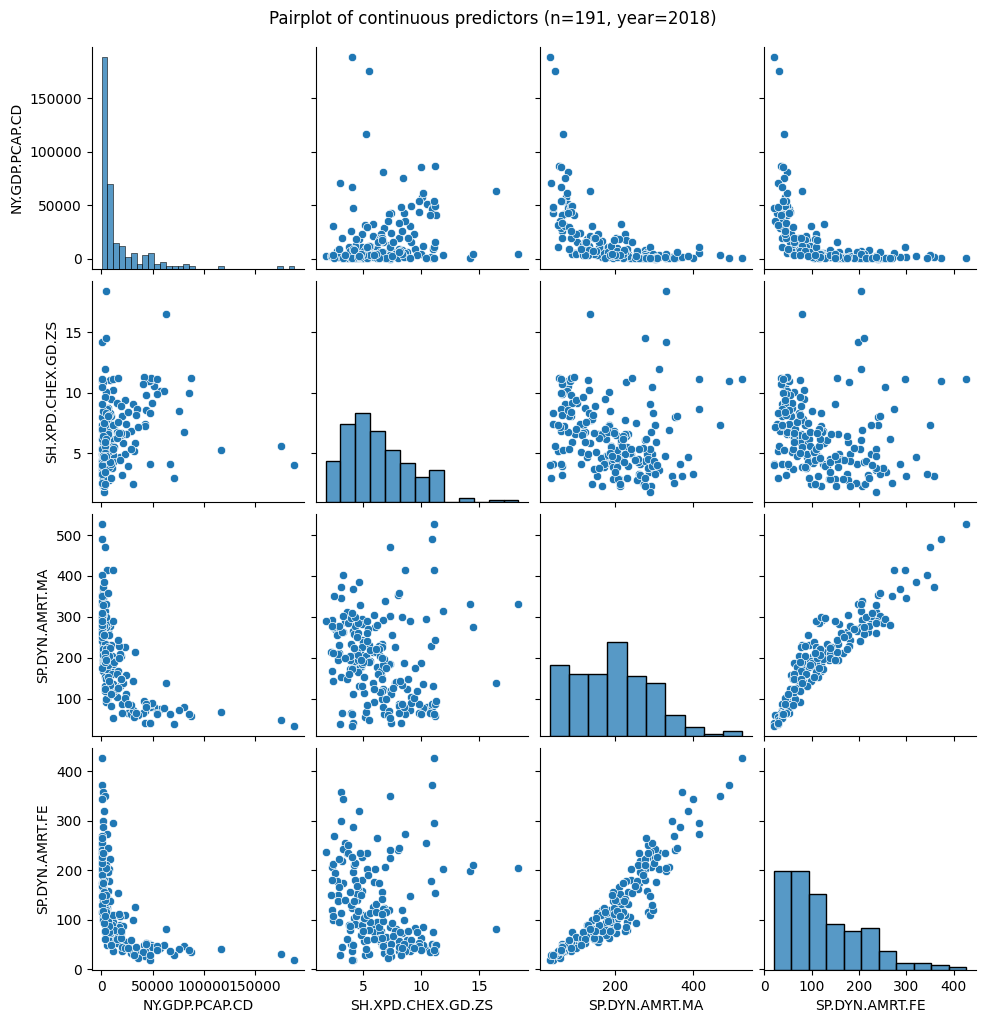

Pairplot saved to /kaggle/working/outputs/predictor_pairplot.png


In [5]:
# Checking correlation and multicollinearity between the four continuous
# predictors before deciding whether male and female adult mortality
# need to be combined into a single variable.


import subprocess
import sys
from pathlib import Path

import pandas as pd

OUTPUTS_DIR = Path("/kaggle/working/outputs")
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)

ANALYSIS_YEAR = 2018

FIVE_INDICATOR_COLUMNS = [
    "NY.GDP.PCAP.CD",
    "SH.XPD.CHEX.GD.ZS",
    "SP.DYN.AMRT.FE",
    "SP.DYN.AMRT.MA",
    "SP.DYN.LE00.IN",
]

CONTINUOUS_PREDICTORS = [
    "NY.GDP.PCAP.CD",
    "SH.XPD.CHEX.GD.ZS",
    "SP.DYN.AMRT.MA",
    "SP.DYN.AMRT.FE",
]

# --- Install dependencies ---
subprocess.check_call([sys.executable, "-m", "pip", "install", "wbgapi", "statsmodels", "seaborn", "-q"])

import wbgapi as wb
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
import matplotlib.pyplot as plt
import seaborn as sns

# --- Rebuild the 2018 dataset for the selected countries and indicators ---
indicator_df = wb.data.DataFrame(
    FIVE_INDICATOR_COLUMNS,
    economy="all",
    time=ANALYSIS_YEAR,
    skipAggs=True,
    labels=False,
    columns="series",
)

income_df = wb.economy.DataFrame()
filtered_income_df = income_df.loc[income_df["aggregate"] == False].copy()

merged = indicator_df.join(filtered_income_df, how="left")

complete_case = merged[FIVE_INDICATOR_COLUMNS].notna().all(axis=1)
complete_and_classified = complete_case & (merged["incomeLevel"] != "INX")

final_df = merged.loc[complete_and_classified].copy()

print(f"Dataset shape (year={ANALYSIS_YEAR}): {final_df.shape}")
print(f"Expected n = 191")
print()

# --- 1. Correlation matrix ---
print("=" * 60)
print("1. Pearson correlation matrix — 4 continuous predictors")
print("=" * 60)
corr_matrix = final_df[CONTINUOUS_PREDICTORS].corr(method="pearson")
print(corr_matrix.round(3).to_string())
print()

# --- 2. VIF ---
print("=" * 60)
print("2. Variance Inflation Factor (VIF) — 4 continuous predictors")
print("=" * 60)
X = final_df[CONTINUOUS_PREDICTORS].dropna()
X_const = add_constant(X)

vif_data = []
for i, col in enumerate(CONTINUOUS_PREDICTORS):
    # +1 offset because add_constant puts 'const' at index 0
    vif_value = variance_inflation_factor(X_const.values, i + 1)
    vif_data.append({"predictor": col, "VIF": round(vif_value, 3)})

vif_df = pd.DataFrame(vif_data)
print(vif_df.to_string(index=False))
print()

flagged = vif_df.loc[vif_df["VIF"] > 5]
if len(flagged) > 0:
    print(f"⚠ {len(flagged)} predictor(s) exceed VIF > 5 (pre-specified threshold):")
    print(flagged.to_string(index=False))
    print("→ Per the pre-specified rule: combine male and female adult mortality into a single overall rate.")
else:
    print("No predictors exceed VIF > 5. Per the pre-specified rule: keep all 4 predictors separate.")
print()

# --- 3. Pairplot ---
print("=" * 60)
print("3. Pairplot of the 4 continuous predictors")
print("=" * 60)
sns.pairplot(final_df[CONTINUOUS_PREDICTORS].dropna())
plt.suptitle(f"Pairplot of continuous predictors (n={len(X)}, year={ANALYSIS_YEAR})", y=1.02)
plt.savefig(OUTPUTS_DIR / "predictor_pairplot.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Pairplot saved to {OUTPUTS_DIR / 'predictor_pairplot.png'}")

In [6]:
# Building the final analysis dataset for 2018: combining male and female
# adult mortality into a single rate (per the VIF-based decision rule) and
# log-transforming GDP per capita to reflect the Preston-curve relationship.


import subprocess
import sys
from pathlib import Path

import numpy as np
import pandas as pd

OUTPUTS_DIR = Path("/kaggle/working/outputs")
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)

ANALYSIS_YEAR = 2018

FIVE_INDICATOR_COLUMNS = [
    "NY.GDP.PCAP.CD",
    "SH.XPD.CHEX.GD.ZS",
    "SP.DYN.AMRT.FE",
    "SP.DYN.AMRT.MA",
    "SP.DYN.LE00.IN",
]

# --- Install wbgapi ---
subprocess.check_call([sys.executable, "-m", "pip", "install", "wbgapi", "-q"])
import wbgapi as wb

# --- Rebuild the 2018 dataset using the same cleaning steps as before ---
indicator_df = wb.data.DataFrame(
    FIVE_INDICATOR_COLUMNS,
    economy="all",
    time=ANALYSIS_YEAR,
    skipAggs=True,
    labels=False,
    columns="series",
)

income_df = wb.economy.DataFrame()
filtered_income_df = income_df.loc[income_df["aggregate"] == False].copy()

merged = indicator_df.join(filtered_income_df, how="left")

complete_case = merged[FIVE_INDICATOR_COLUMNS].notna().all(axis=1)
complete_and_classified = complete_case & (merged["incomeLevel"] != "INX")

df = merged.loc[complete_and_classified].copy()

print(f"Dataset shape (year={ANALYSIS_YEAR}): {df.shape}")
print("Expected: (191, ...)")
print()

# ============================================================
# From here on: applying the mortality-combination and log-transform rules
# ============================================================

df_final = df.copy()

# --- Combine mortality (unweighted mean) ---
df_final['adult_mortality_combined'] = df_final[['SP.DYN.AMRT.MA', 'SP.DYN.AMRT.FE']].mean(axis=1)

# --- Log-transform GDP per capita ---
df_final['log_gdp_per_capita'] = np.log(df_final['NY.GDP.PCAP.CD'])

# --- Sanity checks before finalising ---
assert df_final['NY.GDP.PCAP.CD'].min() > 0, "GDP has non-positive values — log will fail/produce NaN"
assert df_final['adult_mortality_combined'].isna().sum() == 0, "Unexpected NaN in combined mortality"
assert df_final['log_gdp_per_capita'].isna().sum() == 0, "Unexpected NaN in log GDP"

print("All sanity checks passed: GDP > 0, no unexpected NaNs in combined mortality or log GDP.")
print()

# --- Build final analysis dataframe ---
final_cols = [
    'log_gdp_per_capita',
    'SH.XPD.CHEX.GD.ZS',
    'adult_mortality_combined',
    'incomeLevel',
    'SP.DYN.LE00.IN'  # outcome: life expectancy
]
df_analysis = df_final[final_cols].rename(columns={
    'SH.XPD.CHEX.GD.ZS': 'health_expenditure_pct_gdp',
    'SP.DYN.LE00.IN': 'life_expectancy'
})

# --- Dummy-code income level (low income as reference) ---
df_analysis = pd.get_dummies(df_analysis, columns=['incomeLevel'], drop_first=False)

# Manually drop the 'incomeLevel_LIC' dummy to set Low Income as reference category
low_income_col = [c for c in df_analysis.columns if c == 'incomeLevel_LIC']
print("Income dummy columns created:", [c for c in df_analysis.columns if 'incomeLevel' in c])
print("Dropping as reference category:", low_income_col)
df_analysis = df_analysis.drop(columns=low_income_col)

# --- Final checks ---
print()
print("=" * 60)
print("Final analysis dataframe")
print("=" * 60)
print("\nShape:", df_analysis.shape)
print("\nColumn dtypes:\n", df_analysis.dtypes)
print("\nFirst 5 rows:\n", df_analysis.head())
print("\nDescriptive statistics:\n", df_analysis.describe())
print("\nAny remaining missing values?\n", df_analysis.isna().sum())

# Save for the modelling step
save_path = OUTPUTS_DIR / "df_analysis_final.csv"
df_analysis.to_csv(save_path, index=False)
print(f"\nSaved to {save_path}")

Dataset shape (year=2018): (191, 14)
Expected: (191, ...)

All sanity checks passed: GDP > 0, no unexpected NaNs in combined mortality or log GDP.

Income dummy columns created: ['incomeLevel_HIC', 'incomeLevel_LIC', 'incomeLevel_LMC', 'incomeLevel_UMC']
Dropping as reference category: ['incomeLevel_LIC']

Final analysis dataframe

Shape: (191, 7)

Column dtypes:
 log_gdp_per_capita            float64
health_expenditure_pct_gdp    float64
adult_mortality_combined      float64
life_expectancy               float64
incomeLevel_HIC                  bool
incomeLevel_LMC                  bool
incomeLevel_UMC                  bool
dtype: object

First 5 rows:
          log_gdp_per_capita  health_expenditure_pct_gdp  \
economy                                                   
AFG                6.197131                   14.208419   
AGO                7.969645                    2.298875   
ALB                8.682310                    6.590024   
AND               10.664755               

In [7]:
# Re-checking VIF on the final three continuous predictors after the
# log-transform and mortality combination, to confirm no multicollinearity
# remains once the transformations have been applied.


import pandas as pd
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Loading the cleaned dataset saved in the previous script
df_analysis = pd.read_csv('/kaggle/working/outputs/df_analysis_final.csv')

# Final 3 continuous predictors only (post-transform, post-combination)
continuous_predictors = ['log_gdp_per_capita', 'health_expenditure_pct_gdp', 'adult_mortality_combined']

X = df_analysis[continuous_predictors].copy()
X = sm.add_constant(X)  # required for correct VIF calculation

vif_results = pd.DataFrame()
vif_results['Variable'] = X.columns
vif_results['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print("VIF results (final 3 continuous predictors):")
print(vif_results)

# Also print correlation matrix for the same 3 variables, for the Methods write-up
print("\nCorrelation matrix (final 3 continuous predictors):")
print(df_analysis[continuous_predictors].corr())

VIF results (final 3 continuous predictors):
                     Variable         VIF
0                       const  134.089658
1          log_gdp_per_capita    2.503439
2  health_expenditure_pct_gdp    1.109520
3    adult_mortality_combined    2.341587

Correlation matrix (final 3 continuous predictors):
                            log_gdp_per_capita  health_expenditure_pct_gdp  \
log_gdp_per_capita                    1.000000                    0.299634   
health_expenditure_pct_gdp            0.299634                    1.000000   
adult_mortality_combined             -0.754128                   -0.163907   

                            adult_mortality_combined  
log_gdp_per_capita                         -0.754128  
health_expenditure_pct_gdp                 -0.163907  
adult_mortality_combined                    1.000000  


1. Loaded dataset
Shape: (191, 7)
Columns: ['log_gdp_per_capita', 'health_expenditure_pct_gdp', 'adult_mortality_combined', 'life_expectancy', 'incomeLevel_HIC', 'incomeLevel_LMC', 'incomeLevel_UMC']

2. Full OLS model (n=191) — inference
                            OLS Regression Results                            
Dep. Variable:        life_expectancy   R-squared:                       0.960
Model:                            OLS   Adj. R-squared:                  0.959
Method:                 Least Squares   F-statistic:                     744.4
Date:                Wed, 05 Aug 2026   Prob (F-statistic):          3.64e-126
Time:                        15:08:46   Log-Likelihood:                -351.90
No. Observations:                 191   AIC:                             717.8
Df Residuals:                     184   BIC:                             740.6
Df Model:                           6                                         
Covariance Type:            nonrobust             

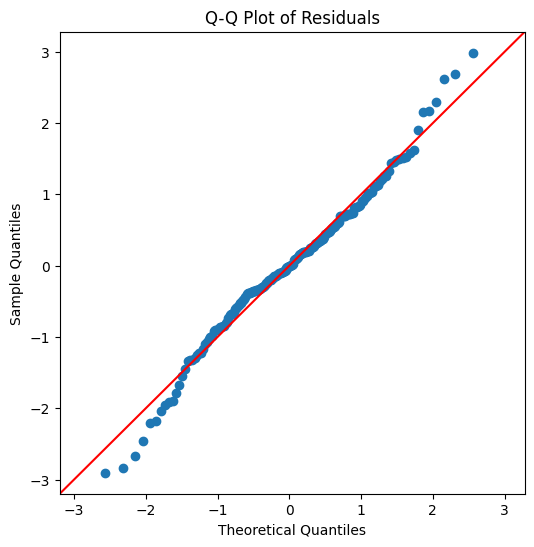

Q-Q plot saved to /kaggle/working/outputs/qq_plot_residuals.png

--- 3b. Homoscedasticity ---
Breusch-Pagan LM statistic: 45.5747, p-value: 0.0000
Homoscedasticity assumption may be violated (threshold: p > 0.05)


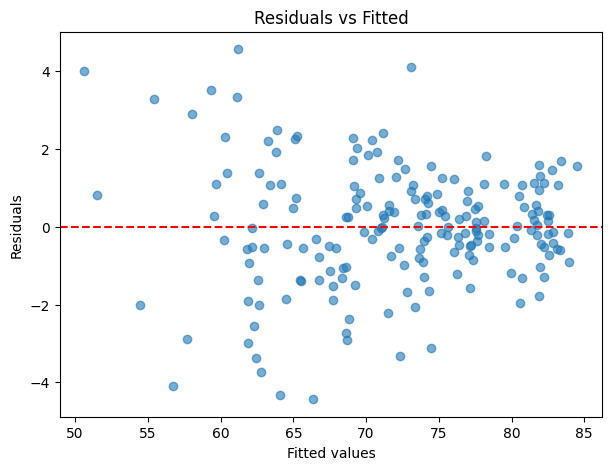

Residuals vs Fitted plot saved to /kaggle/working/outputs/residuals_vs_fitted.png

--- 3c. Independence ---
Durbin-Watson statistic: 1.8152
Acceptable range: approximately 1.5–2.5 (values near 2 indicate no autocorrelation)
Independence assumption appears satisfied

4. Train/test validation (80/20 split, random_state=42)
Training set size: 152, Test set size: 39

In-sample (training) R²:   0.9615
In-sample (training) RMSE: 1.4533

Out-of-sample (test) R²:   0.9469
Out-of-sample (test) RMSE: 1.9755

Summary
Full model (n=191) R²: 0.9604, Adjusted R²: 0.9591
Full model F-statistic: 744.3835, p-value: 0.000000
Shapiro-Wilk (normality): p = 0.0460
Breusch-Pagan (homoscedasticity): p = 0.0000
Durbin-Watson (independence): 1.8152
Train/test validation: in-sample R² = 0.9615, out-of-sample R² = 0.9469


In [8]:
# Fitting the H1 multiple regression, running OLS assumption checks, and
# validating the model with an 80/20 train/test split.


import subprocess
import sys
from pathlib import Path

import numpy as np
import pandas as pd

subprocess.check_call([sys.executable, "-m", "pip", "install", "scikit-learn", "-q"])

import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson
from scipy import stats
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

OUTPUTS_DIR = Path("/kaggle/working/outputs")
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)

DATA_PATH = "/kaggle/working/outputs/df_analysis_final.csv"

# --- 1. Load and confirm ---
df = pd.read_csv(DATA_PATH)
print("=" * 60)
print("1. Loaded dataset")
print("=" * 60)
print("Shape:", df.shape)
print("Columns:", list(df.columns))
print()

PREDICTOR_FORMULA = (
    "life_expectancy ~ log_gdp_per_capita + health_expenditure_pct_gdp + "
    "adult_mortality_combined + incomeLevel_HIC + incomeLevel_LMC + incomeLevel_UMC"
)

# statsmodels formula API needs bool columns as int/float for clean handling
for col in ["incomeLevel_HIC", "incomeLevel_LMC", "incomeLevel_UMC"]:
    df[col] = df[col].astype(int)

# --- 2. Fit full OLS model (n=191, inference) ---
print("=" * 60)
print("2. Full OLS model (n=191) — inference")
print("=" * 60)
full_model = smf.ols(formula=PREDICTOR_FORMULA, data=df).fit()
print(full_model.summary())
print()

# --- 3. Assumption checks on full model residuals ---
print("=" * 60)
print("3. Assumption checks (Week 08 content)")
print("=" * 60)

residuals = full_model.resid
fitted = full_model.fittedvalues

# 3a. Normality: Q-Q plot + Shapiro-Wilk
print("--- 3a. Normality ---")
shapiro_stat, shapiro_p = stats.shapiro(residuals)
print(f"Shapiro-Wilk statistic: {shapiro_stat:.4f}, p-value: {shapiro_p:.4f}")
print(f"Normality assumption {'appears satisfied' if shapiro_p > 0.05 else 'may be violated'} "
      f"(threshold: p > 0.05)")

fig, ax = plt.subplots(figsize=(6, 6))
sm.qqplot(residuals, line="45", fit=True, ax=ax)
ax.set_title("Q-Q Plot of Residuals")
plt.savefig(OUTPUTS_DIR / "qq_plot_residuals.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Q-Q plot saved to {OUTPUTS_DIR / 'qq_plot_residuals.png'}")
print()

# 3b. Homoscedasticity: residuals-vs-fitted + Breusch-Pagan
print("--- 3b. Homoscedasticity ---")
bp_stat, bp_p, bp_fstat, bp_fp = het_breuschpagan(residuals, full_model.model.exog)
print(f"Breusch-Pagan LM statistic: {bp_stat:.4f}, p-value: {bp_p:.4f}")
print(f"Homoscedasticity assumption {'appears satisfied' if bp_p > 0.05 else 'may be violated'} "
      f"(threshold: p > 0.05)")

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(fitted, residuals, alpha=0.6)
ax.axhline(y=0, color="red", linestyle="--")
ax.set_xlabel("Fitted values")
ax.set_ylabel("Residuals")
ax.set_title("Residuals vs Fitted")
plt.savefig(OUTPUTS_DIR / "residuals_vs_fitted.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Residuals vs Fitted plot saved to {OUTPUTS_DIR / 'residuals_vs_fitted.png'}")
print()

# 3c. Independence: Durbin-Watson
print("--- 3c. Independence ---")
dw_stat = durbin_watson(residuals)
print(f"Durbin-Watson statistic: {dw_stat:.4f}")
print("Acceptable range: approximately 1.5–2.5 (values near 2 indicate no autocorrelation)")
print(f"Independence assumption {'appears satisfied' if 1.5 <= dw_stat <= 2.5 else 'may be violated'}")
print()

# --- 4. Train/test validation (separate from inferential model) ---
print("=" * 60)
print("4. Train/test validation (80/20 split, random_state=42)")
print("=" * 60)

feature_cols = [
    "log_gdp_per_capita",
    "health_expenditure_pct_gdp",
    "adult_mortality_combined",
    "incomeLevel_HIC",
    "incomeLevel_LMC",
    "incomeLevel_UMC",
]
X = df[feature_cols]
y = df["life_expectancy"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train_const = sm.add_constant(X_train)
X_test_const = sm.add_constant(X_test)

train_model = sm.OLS(y_train, X_train_const).fit()

# In-sample (training) performance
train_pred = train_model.predict(X_train_const)
train_r2 = r2_score(y_train, train_pred)
train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))

# Out-of-sample (test) performance
test_pred = train_model.predict(X_test_const)
test_r2 = r2_score(y_test, test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))

print(f"Training set size: {len(X_train)}, Test set size: {len(X_test)}")
print()
print(f"In-sample (training) R²:   {train_r2:.4f}")
print(f"In-sample (training) RMSE: {train_rmse:.4f}")
print()
print(f"Out-of-sample (test) R²:   {test_r2:.4f}")
print(f"Out-of-sample (test) RMSE: {test_rmse:.4f}")
print()

print("=" * 60)
print("Summary")
print("=" * 60)
print(f"Full model (n=191) R²: {full_model.rsquared:.4f}, Adjusted R²: {full_model.rsquared_adj:.4f}")
print(f"Full model F-statistic: {full_model.fvalue:.4f}, p-value: {full_model.f_pvalue:.6f}")
print(f"Shapiro-Wilk (normality): p = {shapiro_p:.4f}")
print(f"Breusch-Pagan (homoscedasticity): p = {bp_p:.4f}")
print(f"Durbin-Watson (independence): {dw_stat:.4f}")
print(f"Train/test validation: in-sample R² = {train_r2:.4f}, out-of-sample R² = {test_r2:.4f}")

In [9]:
# Refitting the regression with heteroscedasticity-consistent (HC3) robust
# standard errors to address the Breusch-Pagan violation found previously,
# and checking whether the large condition number is a scale artefact.


import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf

DATA_PATH = "/kaggle/working/outputs/df_analysis_final.csv"

FORMULA = (
    "life_expectancy ~ log_gdp_per_capita + health_expenditure_pct_gdp + "
    "adult_mortality_combined + incomeLevel_HIC + incomeLevel_LMC + incomeLevel_UMC"
)

# --- 1. Load ---
df_analysis = pd.read_csv(DATA_PATH)
for col in ["incomeLevel_HIC", "incomeLevel_LMC", "incomeLevel_UMC"]:
    df_analysis[col] = df_analysis[col].astype(int)

print("=" * 60)
print("1. Loaded dataset")
print("=" * 60)
print("Shape:", df_analysis.shape)
print()

# --- 2. Original (nonrobust) fit, for comparison ---
model_original = smf.ols(FORMULA, data=df_analysis).fit()

# --- 3. Robust (HC3) fit ---
model_robust = smf.ols(FORMULA, data=df_analysis).fit(cov_type="HC3")

print("=" * 60)
print("2. HC3 robust regression — full summary")
print("=" * 60)
print(model_robust.summary())
print()

# --- 4. Side-by-side comparison table ---
print("=" * 60)
print("3. Side-by-side comparison: nonrobust vs. HC3")
print("=" * 60)

comparison = pd.DataFrame({
    "coef_original": model_original.params,
    "coef_robust": model_robust.params,
    "coef_identical": np.isclose(model_original.params, model_robust.params),
    "SE_original": model_original.bse,
    "SE_robust": model_robust.bse,
    "p_original": model_original.pvalues,
    "p_robust": model_robust.pvalues,
})

ci_original = model_original.conf_int()
ci_robust = model_robust.conf_int()
comparison["CI_original_width"] = ci_original[1] - ci_original[0]
comparison["CI_robust_width"] = ci_robust[1] - ci_robust[0]

pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
print(comparison.round(4).to_string())
print()

# --- 5. Significance check under HC3 ---
print("=" * 60)
print("4. Significance check under HC3 (alpha = 0.05)")
print("=" * 60)
sig_check = pd.DataFrame({
    "p_original": model_original.pvalues,
    "sig_original": model_original.pvalues < 0.05,
    "p_robust": model_robust.pvalues,
    "sig_robust": model_robust.pvalues < 0.05,
})
sig_check["significance_changed"] = sig_check["sig_original"] != sig_check["sig_robust"]
print(sig_check.round(4).to_string())
print()
if sig_check["significance_changed"].any():
    print("⚠ At least one predictor's significance changed under HC3.")
else:
    print("All predictors retain the same significance status (p<0.05) under HC3.")
print()

# --- 6. Standardised-predictor condition number check (numerical conditioning only) ---
print("=" * 60)
print("5. Condition number check: standardised continuous predictors")
print("=" * 60)

df_standardized = df_analysis.copy()
continuous_cols = ["log_gdp_per_capita", "health_expenditure_pct_gdp", "adult_mortality_combined"]

for col in continuous_cols:
    df_standardized[col] = (df_standardized[col] - df_standardized[col].mean()) / df_standardized[col].std()

model_standardized = smf.ols(FORMULA, data=df_standardized).fit()

print(f"Original condition number:      {model_original.condition_number:.2f}")
print(f"Standardized condition number:  {model_standardized.condition_number:.2f}")
print()
print("Standardized model coefficients (for reference — interpretation changes to 'per 1 SD'):")
print(model_standardized.params.round(4))
print()
print("Standardized model p-values (should show same significance pattern as original):")
print(model_standardized.pvalues.round(4))

1. Loaded dataset
Shape: (191, 7)

2. HC3 robust regression — full summary
                            OLS Regression Results                            
Dep. Variable:        life_expectancy   R-squared:                       0.960
Model:                            OLS   Adj. R-squared:                  0.959
Method:                 Least Squares   F-statistic:                     555.8
Date:                Wed, 05 Aug 2026   Prob (F-statistic):          4.91e-115
Time:                        15:08:47   Log-Likelihood:                -351.90
No. Observations:                 191   AIC:                             717.8
Df Residuals:                     184   BIC:                             740.6
Df Model:                           6                                         
Covariance Type:                  HC3                                         
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.0/204.0 kB 5.4 MB/s eta 0:00:00
1. Reconstructed income_group column
income_group
High income            64
Upper middle income    58
Lower middle income    47
Low income             22
Name: count, dtype: int64

2. Descriptive statistics: life_expectancy by income_group
                       mean    std  count
income_group                             
Low income           61.498  4.251     22
Lower middle income  66.658  5.544     47
Upper middle income  73.106  3.921     58
High income          79.362  4.538     64



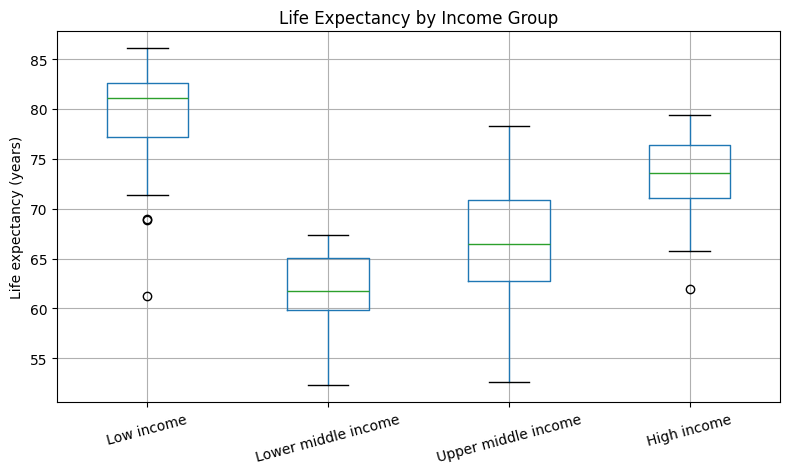

Boxplot saved to /kaggle/working/outputs/life_expectancy_by_income_boxplot.png

3. ANOVA assumption checks
--- 3a. Normality within each group (Shapiro-Wilk) ---
Low income: W=0.9189, p=0.0723 (appears normal)
Lower middle income: W=0.9873, p=0.8830 (appears normal)
Upper middle income: W=0.9476, p=0.0141 (may be non-normal)
High income: W=0.8738, p=0.0000 (may be non-normal)

--- 3b. Homogeneity of variance (Levene's test) ---
Levene's statistic: 1.9947, p-value: 0.1163
Homogeneity of variance appears satisfied (threshold: p > 0.05)

4. One-way ANOVA: life_expectancy ~ income_group
F-statistic: 114.5883
p-value: 0.000000
df between groups: 3, df within groups: 187
ANOVA result: statistically significant at alpha=0.05

5. Effect size (eta-squared)
Eta-squared: 0.6477
(Conventional benchmarks: 0.01=small, 0.06=medium, 0.14=large effect)

6. Tukey HSD post-hoc test (ANOVA was significant)
              Multiple Comparison of Means - Tukey HSD, FWER=0.05               
       group1      

In [10]:
# Testing H2: one-way ANOVA comparing life expectancy across the four
# income groups, with assumption checks and Tukey HSD post-hoc comparisons.


import subprocess
import sys
from pathlib import Path

import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

subprocess.check_call([sys.executable, "-m", "pip", "install", "pingouin", "-q"])
import pingouin as pg

from statsmodels.stats.multicomp import pairwise_tukeyhsd

OUTPUTS_DIR = Path("/kaggle/working/outputs")
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)

DATA_PATH = "/kaggle/working/outputs/df_analysis_final.csv"

# --- 1. Load and reconstruct single categorical income column ---
df = pd.read_csv(DATA_PATH)

def get_income_group(row):
    if row["incomeLevel_HIC"] == 1:
        return "High income"
    elif row["incomeLevel_LMC"] == 1:
        return "Lower middle income"
    elif row["incomeLevel_UMC"] == 1:
        return "Upper middle income"
    else:
        return "Low income"

df["income_group"] = df.apply(get_income_group, axis=1)

print("=" * 60)
print("1. Reconstructed income_group column")
print("=" * 60)
print(df["income_group"].value_counts())
print()

# --- 2. Descriptive statistics + boxplot ---
print("=" * 60)
print("2. Descriptive statistics: life_expectancy by income_group")
print("=" * 60)
group_order = ["Low income", "Lower middle income", "Upper middle income", "High income"]
desc = df.groupby("income_group")["life_expectancy"].agg(["mean", "std", "count"]).reindex(group_order)
print(desc.round(3).to_string())
print()

fig, ax = plt.subplots(figsize=(8, 5))
df.boxplot(column="life_expectancy", by="income_group", ax=ax,
           positions=range(len(group_order)))
ax.set_xticklabels(group_order, rotation=15)
ax.set_title("Life Expectancy by Income Group")
plt.suptitle("")
ax.set_xlabel("")
ax.set_ylabel("Life expectancy (years)")
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / "life_expectancy_by_income_boxplot.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Boxplot saved to {OUTPUTS_DIR / 'life_expectancy_by_income_boxplot.png'}")
print()

# --- 3. ANOVA assumption checks ---
print("=" * 60)
print("3. ANOVA assumption checks")
print("=" * 60)

print("--- 3a. Normality within each group (Shapiro-Wilk) ---")
for group in group_order:
    group_data = df.loc[df["income_group"] == group, "life_expectancy"]
    stat, p = stats.shapiro(group_data)
    verdict = "appears normal" if p > 0.05 else "may be non-normal"
    print(f"{group}: W={stat:.4f}, p={p:.4f} ({verdict})")
print()

print("--- 3b. Homogeneity of variance (Levene's test) ---")
groups_data = [df.loc[df["income_group"] == g, "life_expectancy"] for g in group_order]
levene_stat, levene_p = stats.levene(*groups_data)
print(f"Levene's statistic: {levene_stat:.4f}, p-value: {levene_p:.4f}")
levene_violated = levene_p < 0.05
print(f"Homogeneity of variance {'may be violated' if levene_violated else 'appears satisfied'} "
      f"(threshold: p > 0.05)")
print()

# --- 4. One-way ANOVA ---
print("=" * 60)
print("4. One-way ANOVA: life_expectancy ~ income_group")
print("=" * 60)
f_stat, anova_p = stats.f_oneway(*groups_data)
df_between = len(group_order) - 1
df_within = len(df) - len(group_order)
print(f"F-statistic: {f_stat:.4f}")
print(f"p-value: {anova_p:.6f}")
print(f"df between groups: {df_between}, df within groups: {df_within}")
anova_significant = anova_p < 0.05
print(f"ANOVA result: {'statistically significant' if anova_significant else 'not statistically significant'} "
      f"at alpha=0.05")
print()

# --- 5. Eta-squared effect size ---
print("=" * 60)
print("5. Effect size (eta-squared)")
print("=" * 60)
grand_mean = df["life_expectancy"].mean()
ss_between = sum(len(g) * (g.mean() - grand_mean) ** 2 for g in groups_data)
ss_total = sum((df["life_expectancy"] - grand_mean) ** 2)
eta_squared = ss_between / ss_total
print(f"Eta-squared: {eta_squared:.4f}")
print("(Conventional benchmarks: 0.01=small, 0.06=medium, 0.14=large effect)")
print()

# --- 6. Tukey HSD post-hoc (if ANOVA significant) ---
if anova_significant:
    print("=" * 60)
    print("6. Tukey HSD post-hoc test (ANOVA was significant)")
    print("=" * 60)
    tukey_result = pairwise_tukeyhsd(
        endog=df["life_expectancy"],
        groups=df["income_group"],
        alpha=0.05
    )
    print(tukey_result.summary())
else:
    print("=" * 60)
    print("6. Tukey HSD post-hoc test — SKIPPED")
    print("=" * 60)
    print("ANOVA was not significant; no post-hoc test performed.")
print()

# --- 7. Welch's ANOVA (if Levene's test indicates unequal variances) ---
if levene_violated:
    print("=" * 60)
    print("7. Welch's ANOVA (robustness check — Levene's test indicated unequal variances)")
    print("=" * 60)
    welch_result = pg.welch_anova(dv="life_expectancy", between="income_group", data=df)
    print(welch_result.to_string())
    print()
    welch_p = welch_result["p-unc"].values[0]
    print(f"Welch's ANOVA p-value: {welch_p:.6f}")
    same_conclusion = (welch_p < 0.05) == anova_significant
    print(f"Conclusion {'matches' if same_conclusion else 'DIFFERS FROM'} standard ANOVA "
          f"(standard ANOVA significant: {anova_significant}, Welch's significant: {welch_p < 0.05})")
else:
    print("=" * 60)
    print("7. Welch's ANOVA — SKIPPED")
    print("=" * 60)
    print("Levene's test did not indicate unequal variances; standard ANOVA is appropriate as-is.")

Rebuilt dataset (with country identifiers preserved)
Shape: (191, 19)
Sanity check vs. saved CSV — should also be (191, ...):

1. Cook's Distance — influence diagnostics
Threshold (4/n): 0.0209
Number of observations exceeding threshold: 21 of 191

Top 5 most influential observations (by Cook's Distance):
  1. LSO — Lesotho: Cook's D = 0.16706
  2. SWZ — Eswatini: Cook's D = 0.08820
  3. UGA — Uganda: Cook's D = 0.06732
  4. NGA — Nigeria: Cook's D = 0.06719
  5. GNQ — Equatorial Guinea: Cook's D = 0.06430



/tmp/ipykernel_16/2240541600.py:116: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"  {rank}. {iso3} — {country_name}: Cook's D = {cooks_d[idx]:.5f}")


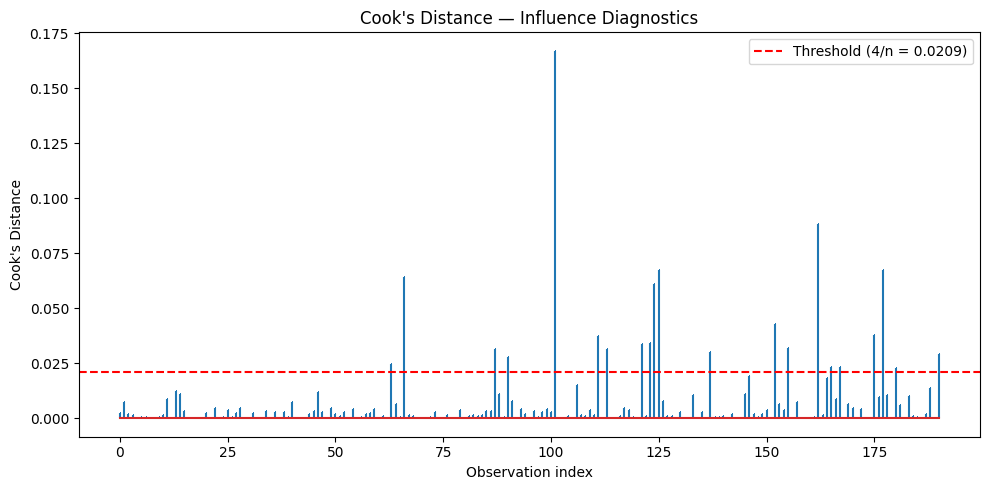

Cook's Distance plot saved to /kaggle/working/outputs/cooks_distance_plot.png

2. 10-Fold Cross-Validation
Fold  1: R² = 0.9505, RMSE = 2.2170
Fold  2: R² = 0.9574, RMSE = 1.4018
Fold  3: R² = 0.9522, RMSE = 1.6920
Fold  4: R² = 0.9530, RMSE = 1.5132
Fold  5: R² = 0.9498, RMSE = 1.7063
Fold  6: R² = 0.9789, RMSE = 1.0869
Fold  7: R² = 0.9586, RMSE = 1.4933
Fold  8: R² = 0.9225, RMSE = 1.8223
Fold  9: R² = 0.9428, RMSE = 1.4758
Fold 10: R² = 0.9627, RMSE = 1.6577

Mean R² across 10 folds:   0.9529 (SD = 0.0137)
Mean RMSE across 10 folds: 1.6066 (SD = 0.2810)

Comparison to single 80/20 split:
  Single split — in-sample R² = 0.9615, out-of-sample R² = 0.9469
  10-fold CV   — mean out-of-sample R² = 0.9529 (SD = 0.0137)
  Consistent with the single-split result.

3. Descriptive statistics — final continuous variables
                               mean     std     min   median      max
log_gdp_per_capita            8.753   1.438   5.504    8.708   12.146
health_expenditure_pct_gdp    6.36

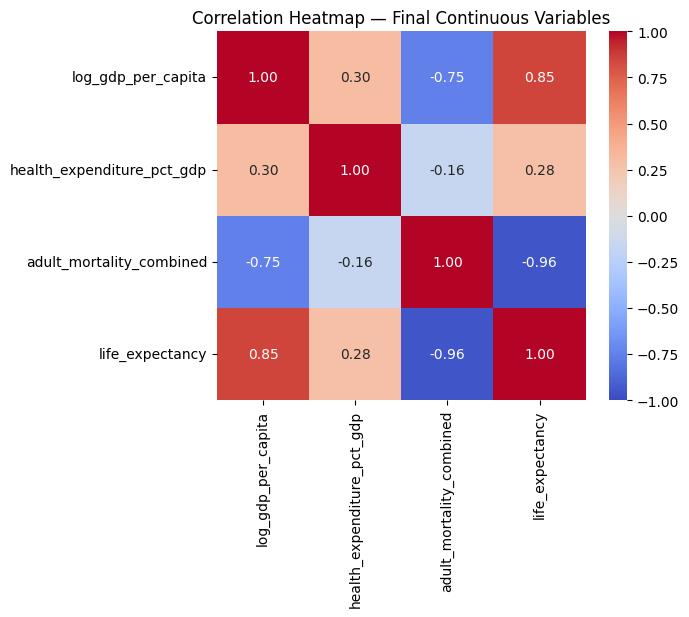

Correlation heatmap saved to /kaggle/working/outputs/correlation_heatmap.png

5. Scatter plot: life expectancy vs log GDP per capita


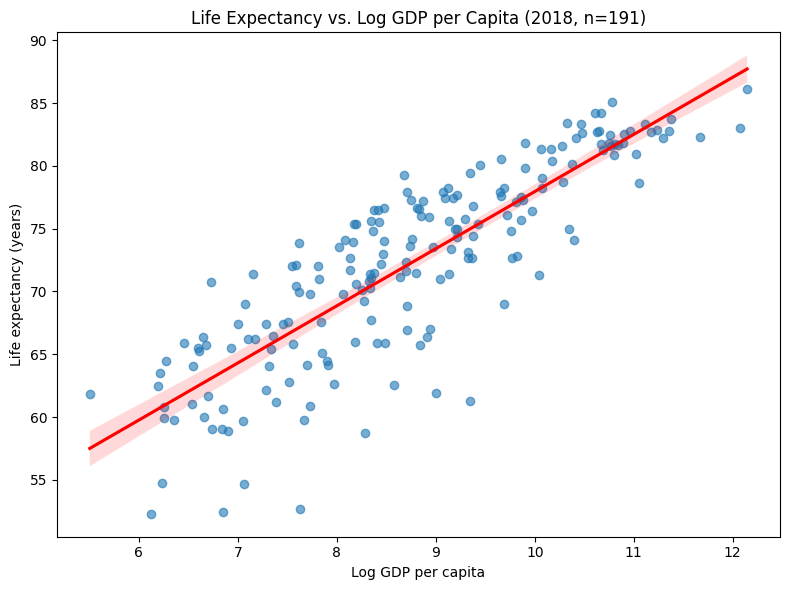

Scatter plot saved to /kaggle/working/outputs/life_expectancy_vs_log_gdp_scatter.png

All diagnostics complete.


In [11]:
# Running final diagnostics before drafting Results and Discussion: Cook's
# Distance for influential observations, 10-fold cross-validation, a full
# descriptive statistics table, a correlation heatmap, and an illustrative
# scatter plot of life expectancy against GDP.


import subprocess
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

subprocess.check_call([sys.executable, "-m", "pip", "install", "wbgapi", "seaborn", "scikit-learn", "-q"])

import wbgapi as wb
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import OLSInfluence
from sklearn.model_selection import KFold
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

OUTPUTS_DIR = Path("/kaggle/working/outputs")
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)

ANALYSIS_YEAR = 2018

FIVE_INDICATOR_COLUMNS = [
    "NY.GDP.PCAP.CD",
    "SH.XPD.CHEX.GD.ZS",
    "SP.DYN.AMRT.FE",
    "SP.DYN.AMRT.MA",
    "SP.DYN.LE00.IN",
]

FORMULA = (
    "life_expectancy ~ log_gdp_per_capita + health_expenditure_pct_gdp + "
    "adult_mortality_combined + incomeLevel_HIC + incomeLevel_LMC + incomeLevel_UMC"
)

CONTINUOUS_PREDICTORS = ["log_gdp_per_capita", "health_expenditure_pct_gdp", "adult_mortality_combined"]
FEATURE_COLS = CONTINUOUS_PREDICTORS + ["incomeLevel_HIC", "incomeLevel_LMC", "incomeLevel_UMC"]

# --- Rebuild the 2018 dataset with country codes/names preserved ---
# (the saved CSV dropped the index, so we rebuild from source rather than
# losing country identification for the influence diagnostics below)
indicator_df = wb.data.DataFrame(
    FIVE_INDICATOR_COLUMNS,
    economy="all",
    time=ANALYSIS_YEAR,
    skipAggs=True,
    labels=False,
    columns="series",
)
income_df = wb.economy.DataFrame()
filtered_income_df = income_df.loc[income_df["aggregate"] == False].copy()
merged = indicator_df.join(filtered_income_df, how="left")
complete_case = merged[FIVE_INDICATOR_COLUMNS].notna().all(axis=1)
complete_and_classified = complete_case & (merged["incomeLevel"] != "INX")
base_df = merged.loc[complete_and_classified].copy()

df = base_df.copy()
df["adult_mortality_combined"] = df[["SP.DYN.AMRT.MA", "SP.DYN.AMRT.FE"]].mean(axis=1)
df["log_gdp_per_capita"] = np.log(df["NY.GDP.PCAP.CD"])
df = df.rename(columns={
    "SH.XPD.CHEX.GD.ZS": "health_expenditure_pct_gdp",
    "SP.DYN.LE00.IN": "life_expectancy",
})
df = pd.get_dummies(df, columns=["incomeLevel"], drop_first=False)
for col in ["incomeLevel_HIC", "incomeLevel_LMC", "incomeLevel_UMC"]:
    if col in df.columns:
        df[col] = df[col].astype(int)
    else:
        df[col] = 0  # in case a category has zero members in this cut

# df.index is now the ISO3 country code (preserved from wbgapi), and
# df["name"] holds the full country name from the income metadata.

print("=" * 60)
print("Rebuilt dataset (with country identifiers preserved)")
print("=" * 60)
print("Shape:", df.shape)
print("Sanity check vs. saved CSV — should also be (191, ...):")
print()

# ============================================================
# 1. Cook's Distance (influence diagnostics)
# ============================================================
print("=" * 60)
print("1. Cook's Distance — influence diagnostics")
print("=" * 60)

model = smf.ols(FORMULA, data=df).fit()  # nonrobust fit is fine for influence stats
influence = OLSInfluence(model)
cooks_d = influence.cooks_distance[0]

n = len(df)
threshold = 4 / n
print(f"Threshold (4/n): {threshold:.4f}")

df_cooks = df.copy()
df_cooks["cooks_d"] = cooks_d
above_threshold = df_cooks.loc[df_cooks["cooks_d"] > threshold]

print(f"Number of observations exceeding threshold: {len(above_threshold)} of {n}")
print()

top5_idx = np.argsort(cooks_d)[::-1][:5]
print("Top 5 most influential observations (by Cook's Distance):")
for rank, idx in enumerate(top5_idx, start=1):
    iso3 = df.index[idx]
    country_name = df.iloc[idx].get("name", iso3)
    print(f"  {rank}. {iso3} — {country_name}: Cook's D = {cooks_d[idx]:.5f}")
print()

fig, ax = plt.subplots(figsize=(10, 5))
ax.stem(range(len(cooks_d)), cooks_d, markerfmt=",")
ax.axhline(y=threshold, color="red", linestyle="--", label=f"Threshold (4/n = {threshold:.4f})")
ax.set_xlabel("Observation index")
ax.set_ylabel("Cook's Distance")
ax.set_title("Cook's Distance — Influence Diagnostics")
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / "cooks_distance_plot.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Cook's Distance plot saved to {OUTPUTS_DIR / 'cooks_distance_plot.png'}")
print()

# ============================================================
# 2. K-Fold Cross-Validation (10 folds)
# ============================================================
print("=" * 60)
print("2. 10-Fold Cross-Validation")
print("=" * 60)

X = df[FEATURE_COLS].values
y = df["life_expectancy"].values

kf = KFold(n_splits=10, shuffle=True, random_state=42)

fold_r2 = []
fold_rmse = []

for fold_num, (train_idx, test_idx) in enumerate(kf.split(X), start=1):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    lr = LinearRegression()
    lr.fit(X_train, y_train)
    preds = lr.predict(X_test)

    r2 = r2_score(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))

    fold_r2.append(r2)
    fold_rmse.append(rmse)

    print(f"Fold {fold_num:2d}: R² = {r2:.4f}, RMSE = {rmse:.4f}")

print()
print(f"Mean R² across 10 folds:   {np.mean(fold_r2):.4f} (SD = {np.std(fold_r2):.4f})")
print(f"Mean RMSE across 10 folds: {np.mean(fold_rmse):.4f} (SD = {np.std(fold_rmse):.4f})")
print()
print("Comparison to single 80/20 split:")
print("  Single split — in-sample R² = 0.9615, out-of-sample R² = 0.9469")
print(f"  10-fold CV   — mean out-of-sample R² = {np.mean(fold_r2):.4f} (SD = {np.std(fold_r2):.4f})")
consistent = abs(np.mean(fold_r2) - 0.9469) < 0.03
print(f"  {'Consistent' if consistent else 'Notably different'} with the single-split result.")
print()

# ============================================================
# 3. Descriptive statistics table
# ============================================================
print("=" * 60)
print("3. Descriptive statistics — final continuous variables")
print("=" * 60)

desc_cols = CONTINUOUS_PREDICTORS + ["life_expectancy"]
desc_table = df[desc_cols].agg(["mean", "std", "min", "median", "max"]).T
print(desc_table.round(3).to_string())
print()

# ============================================================
# 4. Correlation heatmap
# ============================================================
print("=" * 60)
print("4. Correlation heatmap")
print("=" * 60)

corr_cols = CONTINUOUS_PREDICTORS + ["life_expectancy"]
corr_matrix = df[corr_cols].corr()
print(corr_matrix.round(3).to_string())
print()

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax,
            vmin=-1, vmax=1, square=True)
ax.set_title("Correlation Heatmap — Final Continuous Variables")
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / "correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Correlation heatmap saved to {OUTPUTS_DIR / 'correlation_heatmap.png'}")
print()

# ============================================================
# 5. Illustrative scatter plot: life expectancy vs log GDP
# ============================================================
print("=" * 60)
print("5. Scatter plot: life expectancy vs log GDP per capita")
print("=" * 60)

fig, ax = plt.subplots(figsize=(8, 6))
sns.regplot(data=df, x="log_gdp_per_capita", y="life_expectancy",
            scatter_kws={"alpha": 0.6}, line_kws={"color": "red"}, ax=ax)
ax.set_xlabel("Log GDP per capita")
ax.set_ylabel("Life expectancy (years)")
ax.set_title("Life Expectancy vs. Log GDP per Capita (2018, n=191)")
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / "life_expectancy_vs_log_gdp_scatter.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Scatter plot saved to {OUTPUTS_DIR / 'life_expectancy_vs_log_gdp_scatter.png'}")
print()

print("=" * 60)
print("All diagnostics complete.")
print("=" * 60)

In [12]:
# Sensitivity analysis: checking whether the H1 regression's conclusions
# hold once the 21 influential observations flagged by Cook's Distance are
# excluded, and separately checking Lesotho alone as the most extreme case.


import subprocess
import sys
from pathlib import Path

import numpy as np
import pandas as pd

subprocess.check_call([sys.executable, "-m", "pip", "install", "wbgapi", "-q"])

import wbgapi as wb
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import OLSInfluence

ANALYSIS_YEAR = 2018

FIVE_INDICATOR_COLUMNS = [
    "NY.GDP.PCAP.CD",
    "SH.XPD.CHEX.GD.ZS",
    "SP.DYN.AMRT.FE",
    "SP.DYN.AMRT.MA",
    "SP.DYN.LE00.IN",
]

FORMULA = (
    "life_expectancy ~ log_gdp_per_capita + health_expenditure_pct_gdp + "
    "adult_mortality_combined + incomeLevel_HIC + incomeLevel_LMC + incomeLevel_UMC"
)

# --- Rebuild the 2018 dataset with country codes preserved ---
indicator_df = wb.data.DataFrame(
    FIVE_INDICATOR_COLUMNS,
    economy="all",
    time=ANALYSIS_YEAR,
    skipAggs=True,
    labels=False,
    columns="series",
)
income_df = wb.economy.DataFrame()
filtered_income_df = income_df.loc[income_df["aggregate"] == False].copy()
merged = indicator_df.join(filtered_income_df, how="left")
complete_case = merged[FIVE_INDICATOR_COLUMNS].notna().all(axis=1)
complete_and_classified = complete_case & (merged["incomeLevel"] != "INX")
base_df = merged.loc[complete_and_classified].copy()

df = base_df.copy()
df["adult_mortality_combined"] = df[["SP.DYN.AMRT.MA", "SP.DYN.AMRT.FE"]].mean(axis=1)
df["log_gdp_per_capita"] = np.log(df["NY.GDP.PCAP.CD"])
df = df.rename(columns={
    "SH.XPD.CHEX.GD.ZS": "health_expenditure_pct_gdp",
    "SP.DYN.LE00.IN": "life_expectancy",
})
df = pd.get_dummies(df, columns=["incomeLevel"], drop_first=False)
for col in ["incomeLevel_HIC", "incomeLevel_LMC", "incomeLevel_UMC"]:
    if col in df.columns:
        df[col] = df[col].astype(int)
    else:
        df[col] = 0

print("=" * 60)
print("Rebuilt dataset")
print("=" * 60)
print("Shape:", df.shape)
print()

# --- 1 & 2. Compute Cook's Distance, identify the 21 flagged observations ---
full_model = smf.ols(FORMULA, data=df).fit()
influence = OLSInfluence(full_model)
cooks_d = influence.cooks_distance[0]

n = len(df)
threshold = 4 / n

df_with_cooks = df.copy()
df_with_cooks["cooks_d"] = cooks_d.values

flagged_mask = df_with_cooks["cooks_d"] > threshold
flagged_countries = df_with_cooks.loc[flagged_mask].index.tolist()

print(f"Threshold (4/n): {threshold:.4f}")
print(f"Flagged observations (n={len(flagged_countries)}): {flagged_countries}")
print()

# --- 3. Refit HC3 model EXCLUDING the 21 flagged observations ---
df_excl_21 = df_with_cooks.loc[~flagged_mask].copy()
print(f"Sensitivity model (excluding 21 flagged): n = {len(df_excl_21)}")

model_full_hc3 = smf.ols(FORMULA, data=df).fit(cov_type="HC3")
model_excl21_hc3 = smf.ols(FORMULA, data=df_excl_21).fit(cov_type="HC3")

# --- 4. Side-by-side comparison table: full (n=191) vs. excl-21 (n=170) ---
print()
print("=" * 60)
print("4. Comparison: full model (n=191) vs. excluding 21 influential obs (n=170)")
print("=" * 60)

comparison_21 = pd.DataFrame({
    "coef_full": model_full_hc3.params,
    "coef_excl21": model_excl21_hc3.params,
    "p_full": model_full_hc3.pvalues,
    "sig_full": model_full_hc3.pvalues < 0.05,
    "p_excl21": model_excl21_hc3.pvalues,
    "sig_excl21": model_excl21_hc3.pvalues < 0.05,
})
comparison_21["coef_pct_change"] = (
    (comparison_21["coef_excl21"] - comparison_21["coef_full"]) / comparison_21["coef_full"].abs() * 100
)
comparison_21["significance_changed"] = comparison_21["sig_full"] != comparison_21["sig_excl21"]

pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
print(comparison_21.round(4).to_string())
print()

# --- 5. Explicit significance-change statement ---
print("=" * 60)
print("5. Significance change summary (excl-21 model)")
print("=" * 60)
if comparison_21["significance_changed"].any():
    changed = comparison_21.loc[comparison_21["significance_changed"]]
    print(f"⚠ {len(changed)} predictor(s) changed significance status:")
    print(changed.index.tolist())
else:
    print("No predictor changed significance status between the full and excl-21 models.")
print()
print("Coefficient magnitude changes (% change from full model):")
print(comparison_21["coef_pct_change"].round(2).to_string())
print()

# --- 6. Refit excluding ONLY Lesotho (the single most extreme observation) ---
print("=" * 60)
print("6. Comparison: full model (n=191) vs. excluding Lesotho only (n=190)")
print("=" * 60)

# Lesotho's ISO3 code is LSO
df_excl_lesotho = df.loc[df.index != "LSO"].copy()
print(f"Excluding Lesotho only: n = {len(df_excl_lesotho)}")

model_excl_lesotho_hc3 = smf.ols(FORMULA, data=df_excl_lesotho).fit(cov_type="HC3")

comparison_lesotho = pd.DataFrame({
    "coef_full": model_full_hc3.params,
    "coef_excl_lesotho": model_excl_lesotho_hc3.params,
    "p_full": model_full_hc3.pvalues,
    "sig_full": model_full_hc3.pvalues < 0.05,
    "p_excl_lesotho": model_excl_lesotho_hc3.pvalues,
    "sig_excl_lesotho": model_excl_lesotho_hc3.pvalues < 0.05,
})
comparison_lesotho["coef_pct_change"] = (
    (comparison_lesotho["coef_excl_lesotho"] - comparison_lesotho["coef_full"])
    / comparison_lesotho["coef_full"].abs() * 100
)
comparison_lesotho["significance_changed"] = (
    comparison_lesotho["sig_full"] != comparison_lesotho["sig_excl_lesotho"]
)

print(comparison_lesotho.round(4).to_string())
print()

if comparison_lesotho["significance_changed"].any():
    changed = comparison_lesotho.loc[comparison_lesotho["significance_changed"]]
    print(f"⚠ {len(changed)} predictor(s) changed significance status when excluding Lesotho alone:")
    print(changed.index.tolist())
else:
    print("No predictor changed significance status when excluding Lesotho alone.")

print()
print("=" * 60)
print("Sensitivity analysis complete.")
print("=" * 60)

Rebuilt dataset
Shape: (191, 19)

Threshold (4/n): 0.0209
Flagged observations (n=21): ['GIN', 'GNQ', 'KEN', 'KIR', 'LSO', 'MHL', 'MLI', 'MWI', 'NAM', 'NER', 'NGA', 'PLW', 'SLE', 'SOM', 'SWZ', 'TCD', 'THA', 'TUV', 'UGA', 'USA', 'ZWE']

Sensitivity model (excluding 21 flagged): n = 170

4. Comparison: full model (n=191) vs. excluding 21 influential obs (n=170)
                            coef_full  coef_excl21  p_full  sig_full  p_excl21  sig_excl21  coef_pct_change  significance_changed
Intercept                     70.7642      73.3499  0.0000      True    0.0000        True           3.6540                 False
log_gdp_per_capita             1.0380       0.8116  0.0000      True    0.0000        True         -21.8111                 False
health_expenditure_pct_gdp     0.2054       0.2148  0.0000      True    0.0000        True           4.6061                 False
adult_mortality_combined      -0.0646      -0.0671  0.0000      True    0.0000        True          -3.9010           

Rebuilt dataset shape: (191, 14) (expected: (191, ...))

Income group counts:
income_group
High income            64
Upper middle income    58
Lower middle income    47
Low income             22
Name: count, dtype: int64



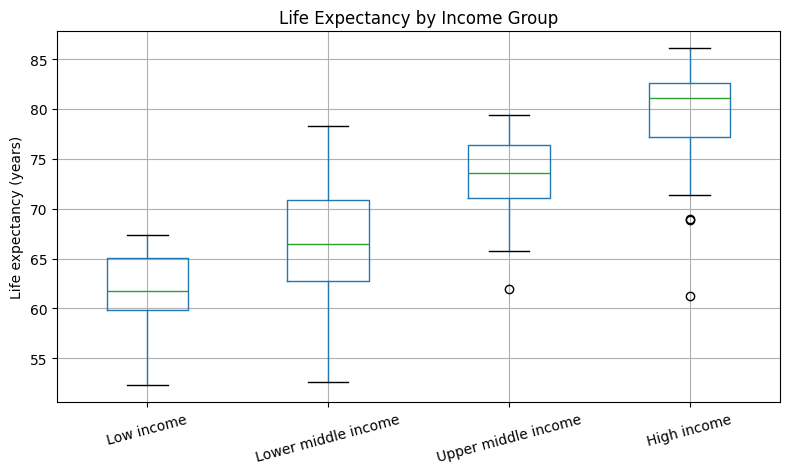

Corrected boxplot saved to /kaggle/working/outputs/life_expectancy_by_income_boxplot_FIXED.png

VERIFY: x-axis order should read left-to-right as:
  Low income → Lower middle income → Upper middle income → High income


In [13]:
# Producing a corrected version of the income-group boxplot: an earlier
# version of this plot sorted the groups alphabetically by default rather
# than by income order, so this version forces the correct Low-to-High order.


import subprocess
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

subprocess.check_call([sys.executable, "-m", "pip", "install", "wbgapi", "-q"])
import wbgapi as wb

OUTPUTS_DIR = Path("/kaggle/working/outputs")
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)

ANALYSIS_YEAR = 2018

FIVE_INDICATOR_COLUMNS = [
    "NY.GDP.PCAP.CD",
    "SH.XPD.CHEX.GD.ZS",
    "SP.DYN.AMRT.FE",
    "SP.DYN.AMRT.MA",
    "SP.DYN.LE00.IN",
]

# --- Rebuild the 2018 dataset ---
indicator_df = wb.data.DataFrame(
    FIVE_INDICATOR_COLUMNS,
    economy="all",
    time=ANALYSIS_YEAR,
    skipAggs=True,
    labels=False,
    columns="series",
)
income_df = wb.economy.DataFrame()
filtered_income_df = income_df.loc[income_df["aggregate"] == False].copy()
merged = indicator_df.join(filtered_income_df, how="left")
complete_case = merged[FIVE_INDICATOR_COLUMNS].notna().all(axis=1)
complete_and_classified = complete_case & (merged["incomeLevel"] != "INX")
df = merged.loc[complete_and_classified].copy()

df = df.rename(columns={"SP.DYN.LE00.IN": "life_expectancy"})

print("Rebuilt dataset shape:", df.shape, "(expected: (191, ...))")
print()

# --- Reconstruct the single categorical income_group column ---
def get_income_group(row):
    if row["incomeLevel"] == "HIC":
        return "High income"
    elif row["incomeLevel"] == "LMC":
        return "Lower middle income"
    elif row["incomeLevel"] == "UMC":
        return "Upper middle income"
    else:
        return "Low income"

df["income_group"] = df.apply(get_income_group, axis=1)

print("Income group counts:")
print(df["income_group"].value_counts())
print()

# --- THE FIX: convert to an ordered categorical BEFORE plotting ---
# This forces pandas/matplotlib to respect this order instead of
# defaulting to alphabetical sorting (the issue with the earlier version).
group_order = ["Low income", "Lower middle income", "Upper middle income", "High income"]
df["income_group"] = pd.Categorical(df["income_group"], categories=group_order, ordered=True)

# --- Corrected boxplot ---
fig, ax = plt.subplots(figsize=(8, 5))
df.boxplot(column="life_expectancy", by="income_group", ax=ax)
ax.set_title("Life Expectancy by Income Group")
plt.suptitle("")
ax.set_xlabel("")
ax.set_ylabel("Life expectancy (years)")
plt.xticks(rotation=15)
plt.tight_layout()

save_path = OUTPUTS_DIR / "life_expectancy_by_income_boxplot_FIXED.png"
plt.savefig(save_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Corrected boxplot saved to {save_path}")
print()
print("VERIFY: x-axis order should read left-to-right as:")
print("  Low income → Lower middle income → Upper middle income → High income")